In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
from scipy import stats

In [3]:
sns.color_palette()

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

## Interlimb data

## Hexa 4 legs

In [84]:
df = pd.read_csv('data/integrated_data_gamma.csv')
df

,Time (s),o1,o2,fwd_force,filtered_force_1,filtered_force_2,filtered_force_3,filtered_force_4,error_force,gamma_1,gamma_2,gamma_3,gamma_4
0,0.00,0.734,-0.774,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00
1,0.02,0.670,-0.859,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00
2,0.04,0.603,-0.883,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00
3,0.06,0.535,-0.886,0.0,0.072,0.082,0.072,0.082,0.072,0.000,0.000,0.000,0.00
4,0.08,0.463,-0.883,0.0,0.256,0.305,0.256,0.305,0.256,0.000,0.000,0.000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1890,37.80,0.430,-0.847,0.0,1.000,0.000,0.000,1.000,1.000,0.021,0.011,0.021,0.01
1891,37.82,0.185,-0.807,0.0,1.000,0.000,0.000,1.000,1.000,0.021,0.011,0.022,0.01
1892,37.84,-0.123,-0.777,0.0,1.000,0.000,0.000,1.000,1.000,0.021,0.011,0.021,0.01
1893,37.86,-0.493,-0.727,0.0,1.000,0.000,0.000,1.000,1.000,0.021,0.011,0.021,0.01


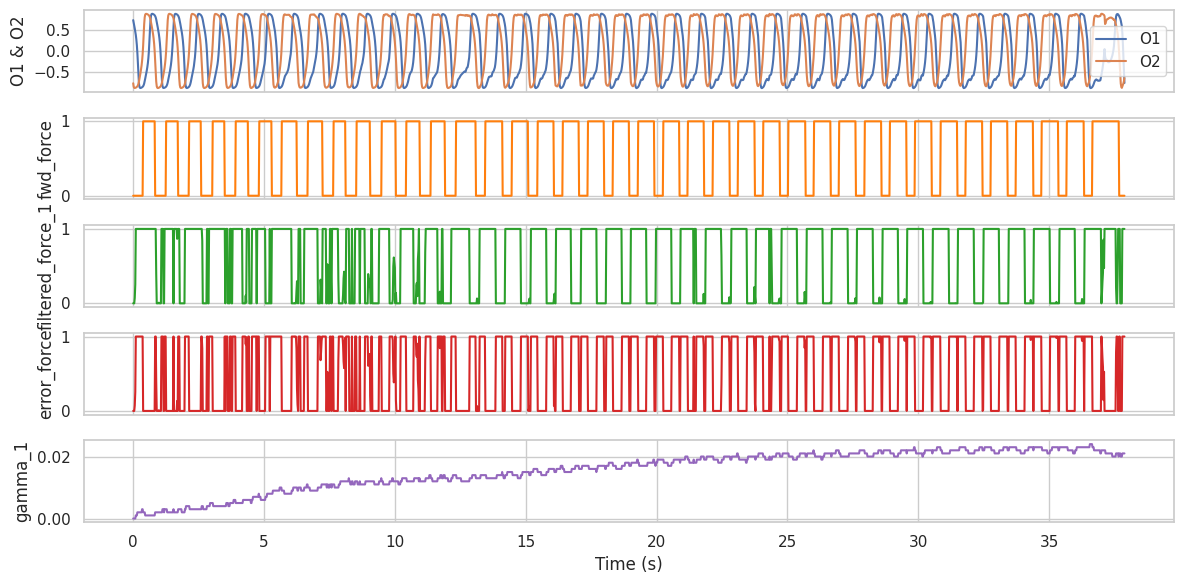

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv('data/integrated_data_gamma.csv')

# Use the correct column name for time
time = df['Time (s)']
O1 = df['o1']
O2 = df['o2']
fwd_force = df['fwd_force']
filtered_force = df['filtered_force_1']
error_force = df['error_force']
gamma_1 = df['gamma_1']

# Create subplots
fig, axs = plt.subplots(5, 1, figsize=(12, 6), sharex=True)

# Plot (a) O1 and O2
axs[0].plot(time, O1, label='O1')
axs[0].plot(time, O2, label='O2')
axs[0].set_ylabel('O1 & O2')
axs[0].legend()
axs[0].grid(True)

# Plot (b) fwd_force
axs[1].plot(time, fwd_force, color='tab:orange')
axs[1].set_ylabel('fwd_force')
axs[1].grid(True)

# Plot (c) filtered_force
axs[2].plot(time, filtered_force, color='tab:green')
axs[2].set_ylabel('filtered_force_1')
axs[2].grid(True)

# Plot (d) error_force
axs[3].plot(time, error_force, color='tab:red')
axs[3].set_ylabel('error_force')
axs[3].grid(True)

# Plot (e) gamma_1
axs[4].plot(time, gamma_1, color='tab:purple')
axs[4].set_ylabel('gamma_1')
axs[4].set_xlabel('Time (s)')
axs[4].grid(True)

plt.tight_layout()
plt.show()


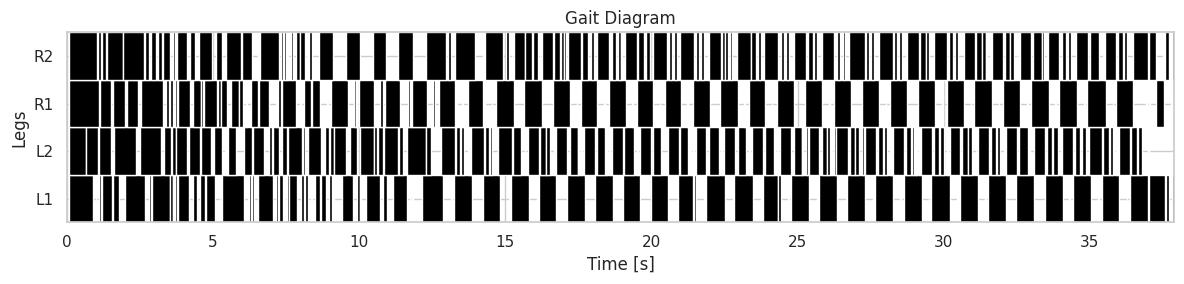

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
df = pd.read_csv('data/integrated_data_gamma.csv')

# Use correct columns
time = df['Time (s)']
forces = [
    df['filtered_force_1'],
    df['filtered_force_2'],
    df['filtered_force_3'],
    df['filtered_force_4']
]

leg_labels = ['L1', 'L2', 'R1', 'R2']  # Change as needed

# Threshold for stance detection (adjust!)
threshold = -0.0

# Create binary stance matrix
stance = []
for force in forces:
    stance.append(force > threshold)

stance = np.array(stance)

# Plot
fig, ax = plt.subplots(figsize=(12, 3))

# Loop over legs
for i in range(stance.shape[0]):
    # Find continuous stance phases
    in_stance = False
    start_time = None
    for j in range(len(time)):
        if stance[i, j] and not in_stance:
            in_stance = True
            start_time = time[j]
        elif not stance[i, j] and in_stance:
            in_stance = False
            end_time = time[j]
            ax.broken_barh([(start_time, end_time - start_time)],
                           (i - 0.5, 1.0),
                           facecolors='black')
    # If still in stance at end
    if in_stance:
        end_time = time.iloc[-1]
        ax.broken_barh([(start_time, end_time - start_time)],
                       (i - 0.5, 1.0),
                       facecolors='black')

# Labels and formatting
ax.set_yticks(range(len(leg_labels)))
ax.set_yticklabels(leg_labels)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Legs')
ax.set_title('Gait Diagram')
ax.set_xlim(time.iloc[0], time.iloc[-1])
ax.set_ylim(-0.5, len(leg_labels)-0.5)
ax.grid(True, axis='x')

plt.tight_layout()
plt.show()


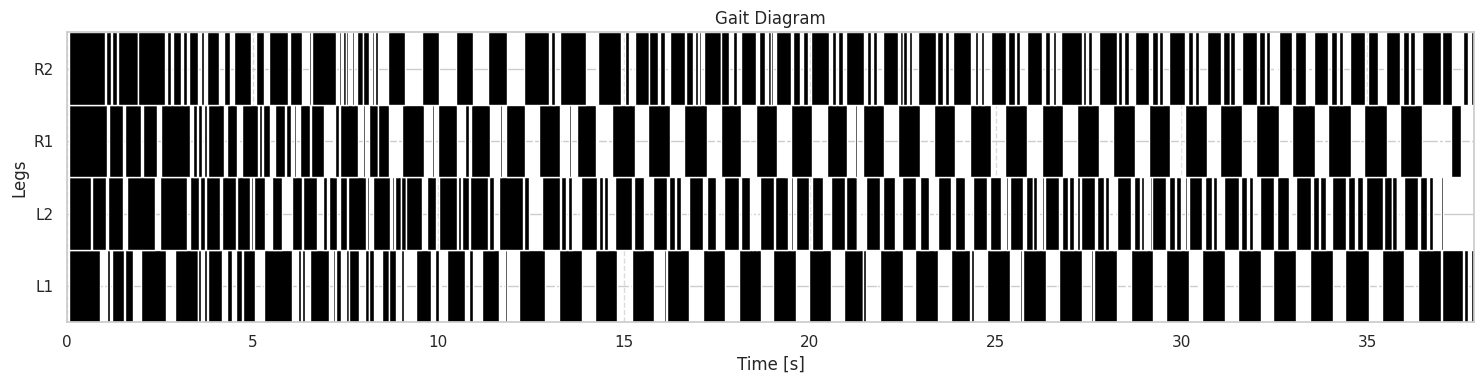

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns # Import seaborn

# Load CSV
try:
    df = pd.read_csv('data/integrated_data_gamma.csv')
except FileNotFoundError:
    print("Error: 'data/integrated_data_gamma.csv' not found.")
    print("Please ensure the CSV file is in the 'data' directory relative to this script.")
    # Create dummy data for demonstration if file not found
    print("Generating dummy data for demonstration purposes.")
    total_time = 42 # seconds
    sampling_rate = 100 # samples per second
    num_samples = int(total_time * sampling_rate)
    time = pd.Series(np.linspace(0, total_time, num_samples))
    dummy_forces = []
    for _ in range(4): # 4 legs
        # Simulate some random force data
        force_series = np.sin(time * np.random.uniform(0.5, 2)) * 50 + np.random.uniform(0, 20)
        force_series[force_series < 0] = 0 # Ensure forces are non-negative
        dummy_forces.append(pd.Series(force_series))
    forces = dummy_forces
    leg_labels = ['L1', 'L2', 'R1', 'R2']
    # Create a dummy DataFrame to match the structure for the rest of the code
    df = pd.DataFrame({'Time (s)': time,
                       'filtered_force_1': forces[0],
                       'filtered_force_2': forces[1],
                       'filtered_force_3': forces[2],
                       'filtered_force_4': forces[3]})


# Use correct columns
time = df['Time (s)']
forces = [
    df['filtered_force_1'],
    df['filtered_force_2'],
    df['filtered_force_3'],
    df['filtered_force_4']
]

leg_labels = ['L1', 'L2', 'R1', 'R2']  # Change as needed

# Threshold for stance detection (adjust as necessary for your data!)
# A value of 0.0 might be too low if your sensors have noise or baseline readings.
# Consider a slightly positive value if forces are always positive.
threshold = 0.0

# Create binary stance matrix
stance = []
for force in forces:
    stance.append(force > threshold)

stance = np.array(stance)

# --- Plotting with Seaborn styling ---

# Apply a seaborn style for better aesthetics
sns.set_theme(style="whitegrid") # You can try "darkgrid", "white", "dark", "ticks"

fig, ax = plt.subplots(figsize=(15, 4)) # Adjusted figure size for better visualization

# Loop over legs
for i in range(stance.shape[0]):
    # Find continuous stance phases
    in_stance = False
    start_time = None
    for j in range(len(time)):
        if stance[i, j] and not in_stance:
            # Start of a stance phase
            in_stance = True
            start_time = time.iloc[j]
        elif not stance[i, j] and in_stance:
            # End of a stance phase
            in_stance = False
            end_time = time.iloc[j]
            # Plot the broken bar for this stance phase
            ax.broken_barh([(start_time, end_time - start_time)],
                           (i - 0.5, 1.0), # y-range for the bar
                           facecolors='black')
    # If still in stance at the very end of the data
    if in_stance:
        end_time = time.iloc[-1]
        ax.broken_barh([(start_time, end_time - start_time)],
                       (i - 0.5, 1.0),
                       facecolors='black')

# Labels and formatting
ax.set_yticks(range(len(leg_labels)))
ax.set_yticklabels(leg_labels)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Legs')
ax.set_title('Gait Diagram')
ax.set_xlim(time.iloc[0], time.iloc[-1]) # Set x-axis limits from the time data
ax.set_ylim(-0.5, len(leg_labels) - 0.5) # Set y-axis limits to properly display bars

# Seaborn's set_theme often handles grid, but we can explicitly set it for clarity
# If using "whitegrid" or "darkgrid", seaborn will add a grid by default.
# We explicitly set axis='x' here to match the previous plot's grid style.
ax.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


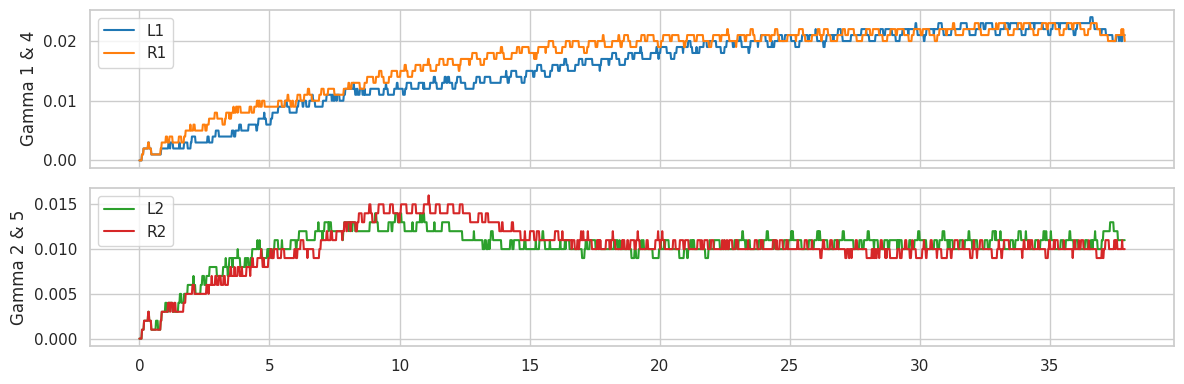

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv('data/integrated_data_gamma.csv')

# Extract time and gamma signals
time = df['Time (s)']
gamma_1 = df['gamma_1']
gamma_2 = df['gamma_2']
gamma_3 = df['gamma_3']
gamma_4 = df['gamma_4']

# Create subplots: 3 rows, 1 column
fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharex=True)

# Plot gamma_1 and gamma_4
axs[0].plot(time, gamma_1, label='L1', color='tab:blue')
axs[0].plot(time, gamma_3, label='R1', color='tab:orange')
axs[0].set_ylabel('Gamma 1 & 4')
axs[0].legend()
axs[0].grid(True)

# Plot gamma_2 and gamma_5
axs[1].plot(time, gamma_2, label='L2', color='tab:green')
axs[1].plot(time, gamma_4, label='R2', color='tab:red')
axs[1].set_ylabel('Gamma 2 & 5')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


## Hexapod 6 Legs 

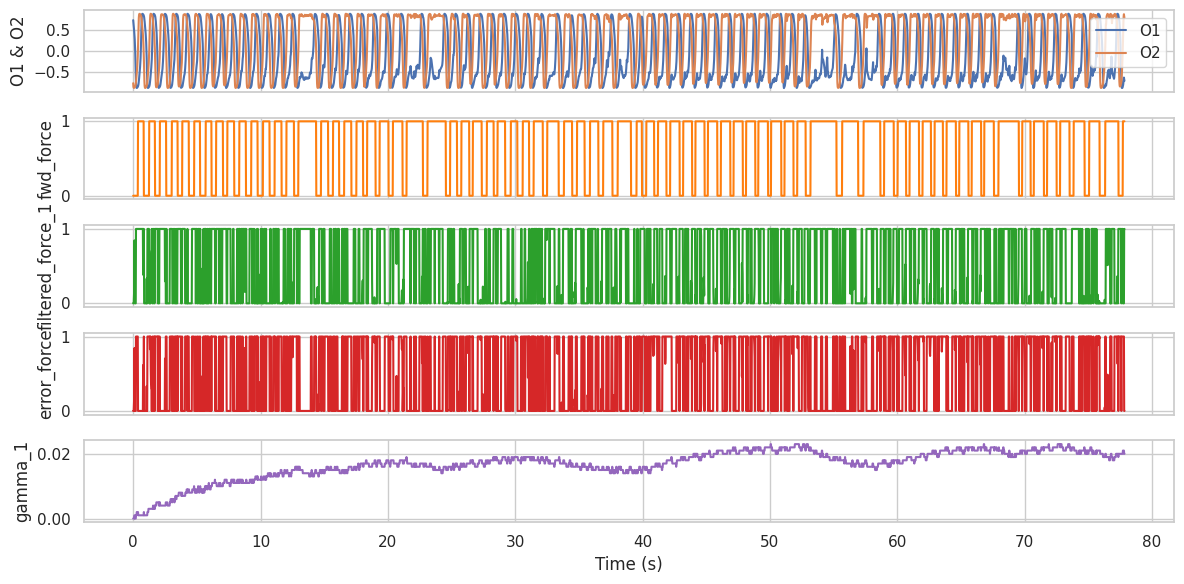

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv('data/integrated_data_gamma_hex6legs.csv')

# Use the correct column name for time
time = df['Time (s)']
O1 = df['o1']
O2 = df['o2']
fwd_force = df['fwd_force']
filtered_force = df['filtered_force_1']
error_force = df['error_force']
gamma_1 = df['gamma_1']

# Create subplots
fig, axs = plt.subplots(5, 1, figsize=(12, 6), sharex=True)

# Plot (a) O1 and O2
axs[0].plot(time, O1, label='O1')
axs[0].plot(time, O2, label='O2')
axs[0].set_ylabel('O1 & O2')
axs[0].legend()
axs[0].grid(True)

# Plot (b) fwd_force
axs[1].plot(time, fwd_force, color='tab:orange')
axs[1].set_ylabel('fwd_force')
axs[1].grid(True)

# Plot (c) filtered_force
axs[2].plot(time, filtered_force, color='tab:green')
axs[2].set_ylabel('filtered_force_1')
axs[2].grid(True)

# Plot (d) error_force
axs[3].plot(time, error_force, color='tab:red')
axs[3].set_ylabel('error_force')
axs[3].grid(True)

# Plot (e) gamma_1
axs[4].plot(time, gamma_1, color='tab:purple')
axs[4].set_ylabel('gamma_1')
axs[4].set_xlabel('Time (s)')
axs[4].grid(True)

plt.tight_layout()
plt.show()

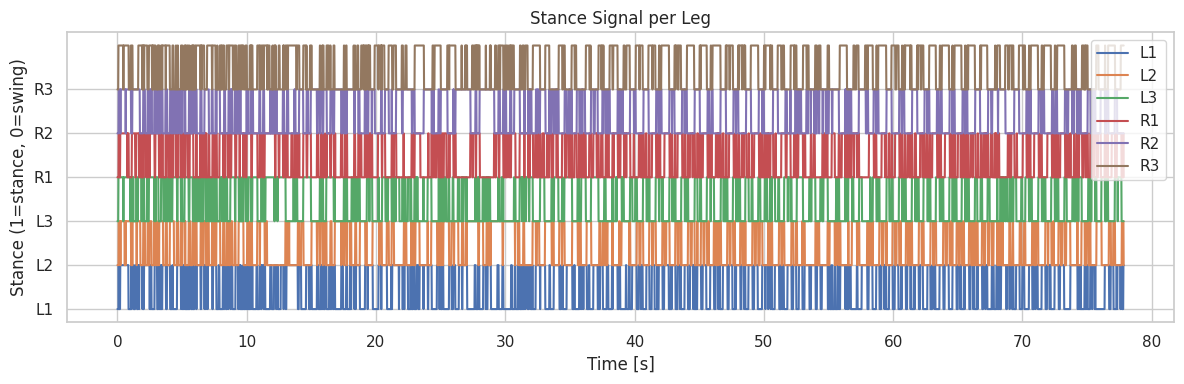

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
df = pd.read_csv('data/integrated_data_gamma_hex6legs.csv')

# Use correct columns
time = df['Time (s)']
forces = [
    df['filtered_force_1'],
    df['filtered_force_2'],
    df['filtered_force_3'],
    df['filtered_force_4'],
    df['filtered_force_5'],
    df['filtered_force_6']
]

# Update leg labels
leg_labels = ['L1', 'L2', 'L3', 'R1', 'R2', 'R3']  # Example for hexapod

# Threshold for stance detection (adjust!)
threshold = 0.3

# Create binary stance matrix
stance = []
for force in forces:
    stance.append(force > threshold)

stance = np.array(stance)

# Plot stance signals for each leg
fig2, ax2 = plt.subplots(figsize=(12, 4))
for i in range(stance.shape[0]):
    ax2.plot(time, stance[i].astype(int) + i, label=leg_labels[i])
ax2.set_yticks(range(len(leg_labels)))
ax2.set_yticklabels(leg_labels)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Stance (1=stance, 0=swing)')
ax2.set_title('Stance Signal per Leg')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()


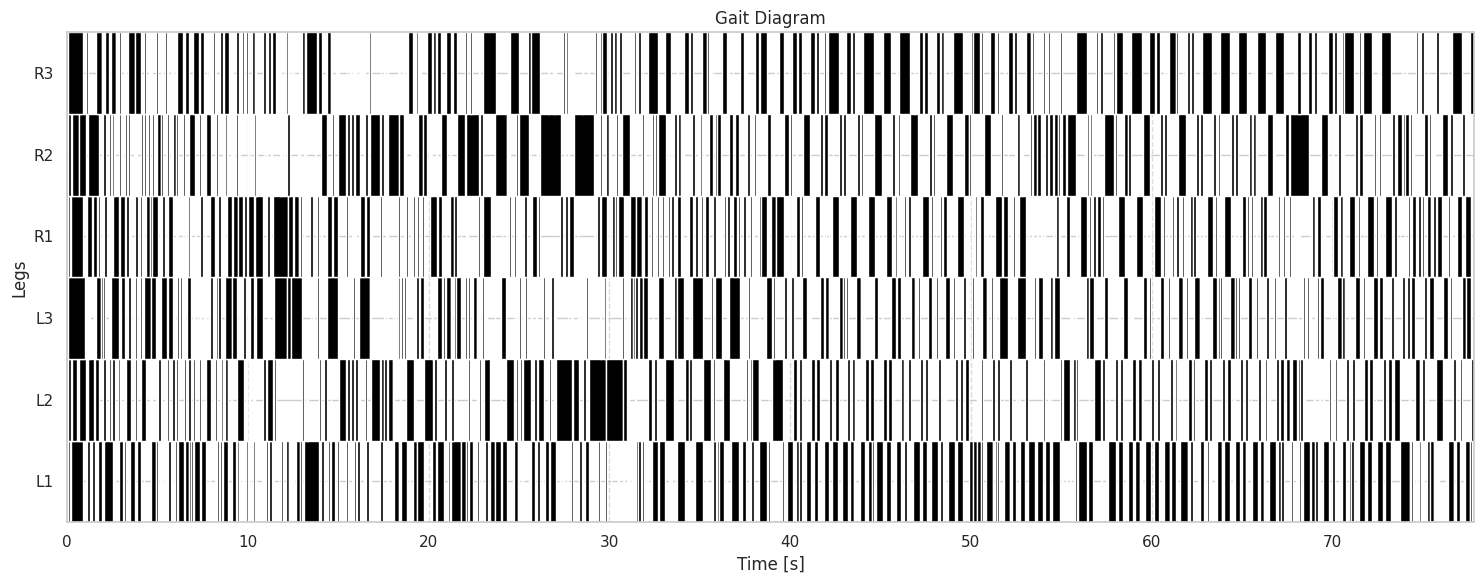

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns # Import seaborn

# Load CSV
try:
    df = pd.read_csv('data/integrated_data_gamma_hex6legs.csv') # Updated CSV file name
except FileNotFoundError:
    print("Error: 'data/integrated_data_gamma_hex6legs.csv' not found.")
    print("Please ensure the CSV file is in the 'data' directory relative to this script.")
    # Create dummy data for demonstration if file not found
    print("Generating dummy data for demonstration purposes.")
    total_time = 42 # seconds
    sampling_rate = 100 # samples per second
    num_samples = int(total_time * sampling_rate)
    time = pd.Series(np.linspace(0, total_time, num_samples))
    dummy_forces = []
    num_legs_dummy = 6 # Changed to 6 legs for dummy data
    for _ in range(num_legs_dummy):
        # Simulate some random force data
        force_series = np.sin(time * np.random.uniform(0.5, 2)) * 50 + np.random.uniform(0, 20)
        force_series[force_series < 0] = 0 # Ensure forces are non-negative
        dummy_forces.append(pd.Series(force_series))
    leg_labels = ['L1', 'L2', 'L3', 'R1', 'R2', 'R3'] # Updated dummy leg labels
    # Create a dummy DataFrame to match the structure for the rest of the code
    df = pd.DataFrame({'Time (s)': time,
                       'filtered_force_1': dummy_forces[0],
                       'filtered_force_2': dummy_forces[1],
                       'filtered_force_3': dummy_forces[2],
                       'filtered_force_4': dummy_forces[3],
                       'filtered_force_5': dummy_forces[4], # Added for 6 legs
                       'filtered_force_6': dummy_forces[5]}) # Added for 6 legs


# Use correct columns
time = df['Time (s)']
forces = [
    df['filtered_force_1'],
    df['filtered_force_2'],
    df['filtered_force_3'],
    df['filtered_force_4'],
    df['filtered_force_5'], # Added for 6 legs
    df['filtered_force_6']  # Added for 6 legs
]

# Update leg labels for 6 legs
leg_labels = ['L1', 'L2', 'L3', 'R1', 'R2', 'R3']

# Threshold for stance detection (adjust as necessary for your data!)
# A value of 0.0 might be too low if your sensors have noise or baseline readings.
# Consider a slightly positive value if forces are always positive.
threshold = 0.00001

# Create binary stance matrix
stance = []
for force in forces:
    stance.append(force > threshold)

stance = np.array(stance)

# --- Plotting with Seaborn styling ---

# Apply a seaborn style for better aesthetics
sns.set_theme(style="whitegrid") # You can try "darkgrid", "white", "dark", "ticks"

# Adjusted figure height for 6 legs
fig, ax = plt.subplots(figsize=(15, 6)) # Increased height for more legs

# Loop over legs
for i in range(stance.shape[0]):
    # Find continuous stance phases
    in_stance = False
    start_time = None
    for j in range(len(time)):
        if stance[i, j] and not in_stance:
            # Start of a stance phase
            in_stance = True
            start_time = time.iloc[j]
        elif not stance[i, j] and in_stance:
            # End of a stance phase
            in_stance = False
            end_time = time.iloc[j]
            # Plot the broken bar for this stance phase
            ax.broken_barh([(start_time, end_time - start_time)],
                           (i - 0.5, 1.0), # y-range for the bar
                           facecolors='black')
    # If still in stance at the very end of the data
    if in_stance:
        end_time = time.iloc[-1]
        ax.broken_barh([(start_time, end_time - start_time)],
                       (i - 0.5, 1.0),
                       facecolors='black')

# Labels and formatting
ax.set_yticks(range(len(leg_labels)))
ax.set_yticklabels(leg_labels)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Legs')
ax.set_title('Gait Diagram')
ax.set_xlim(time.iloc[0], time.iloc[-1]) # Set x-axis limits from the time data
ax.set_ylim(-0.5, len(leg_labels) - 0.5) # Set y-axis limits to properly display bars

# Seaborn's set_theme often handles grid, but we can explicitly set it for clarity
# If using "whitegrid" or "darkgrid", seaborn will add a grid by default.
# We explicitly set axis='x' here to match the previous plot's grid style.
ax.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


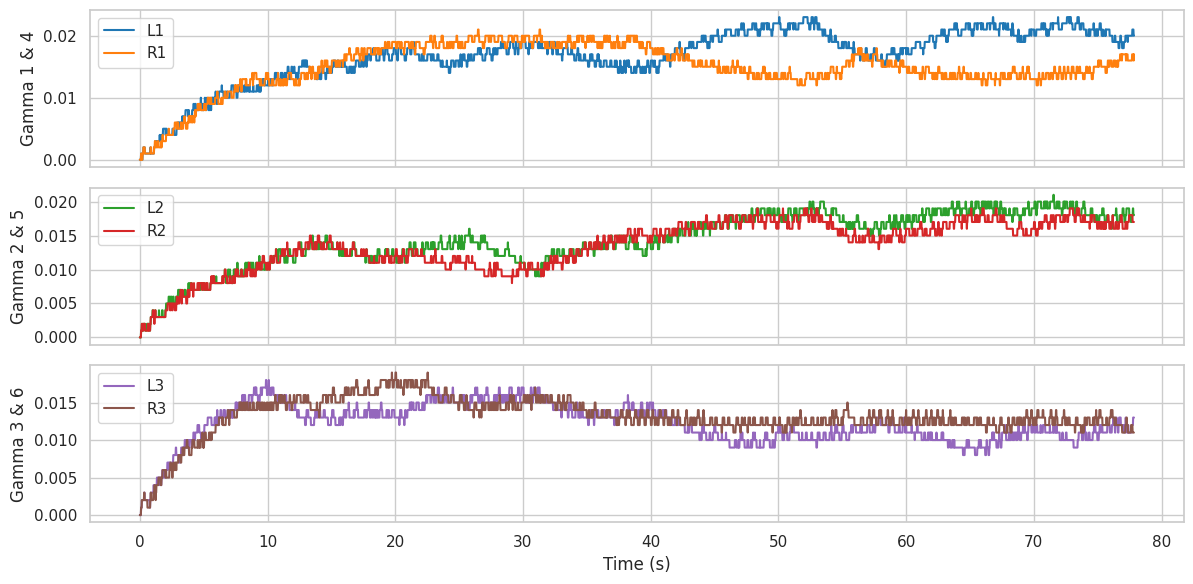

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv('data/integrated_data_gamma_hex6legs.csv') # Updated CSV file name

# Extract time and gamma signals
time = df['Time (s)']
gamma_1 = df['gamma_1']
gamma_2 = df['gamma_2']
gamma_3 = df['gamma_3']
gamma_4 = df['gamma_4']
gamma_5 = df['gamma_5']
gamma_6 = df['gamma_6']

# Create subplots: 3 rows, 1 column
fig, axs = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

# Plot gamma_1 and gamma_4
axs[0].plot(time, gamma_1, label='L1', color='tab:blue')
axs[0].plot(time, gamma_4, label='R1', color='tab:orange')
axs[0].set_ylabel('Gamma 1 & 4')
axs[0].legend()
axs[0].grid(True)

# Plot gamma_2 and gamma_5
axs[1].plot(time, gamma_2, label='L2', color='tab:green')
axs[1].plot(time, gamma_5, label='R2', color='tab:red')
axs[1].set_ylabel('Gamma 2 & 5')
axs[1].legend()
axs[1].grid(True)

# Plot gamma_3 and gamma_6
axs[2].plot(time, gamma_3, label='L3', color='tab:purple')
axs[2].plot(time, gamma_6, label='R3', color='tab:brown')
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('Gamma 3 & 6')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

## Quadruped 4 legs Robot

In [79]:
df = pd.read_csv('data/integrated_data_gamma_quad4leg.csv')
df

,Time (s),o1,o2,fwd_force,filtered_force_1,filtered_force_2,filtered_force_3,filtered_force_4,error_force,gamma_1,gamma_2,gamma_3,gamma_4
0,0.00,0.734,-0.774,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.00
1,0.02,0.670,-0.859,0.0,0.548,0.313,0.548,0.313,0.548,0.000,0.00,0.000,0.00
2,0.04,0.603,-0.883,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.00
3,0.06,0.535,-0.886,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.00
4,0.08,0.461,-0.883,0.0,1.000,0.000,1.000,0.000,1.000,0.001,0.00,0.001,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1873,37.46,-0.512,0.882,1.0,1.000,0.000,0.000,0.219,0.000,0.017,0.01,0.014,0.01
1874,37.48,-0.527,0.847,1.0,1.000,0.000,0.000,0.701,0.000,0.017,0.01,0.014,0.01
1875,37.50,-0.750,0.661,1.0,1.000,0.000,0.000,1.000,0.000,0.017,0.01,0.014,0.01
1876,37.52,-0.811,0.663,1.0,1.000,0.118,0.000,1.000,0.000,0.017,0.01,0.013,0.01


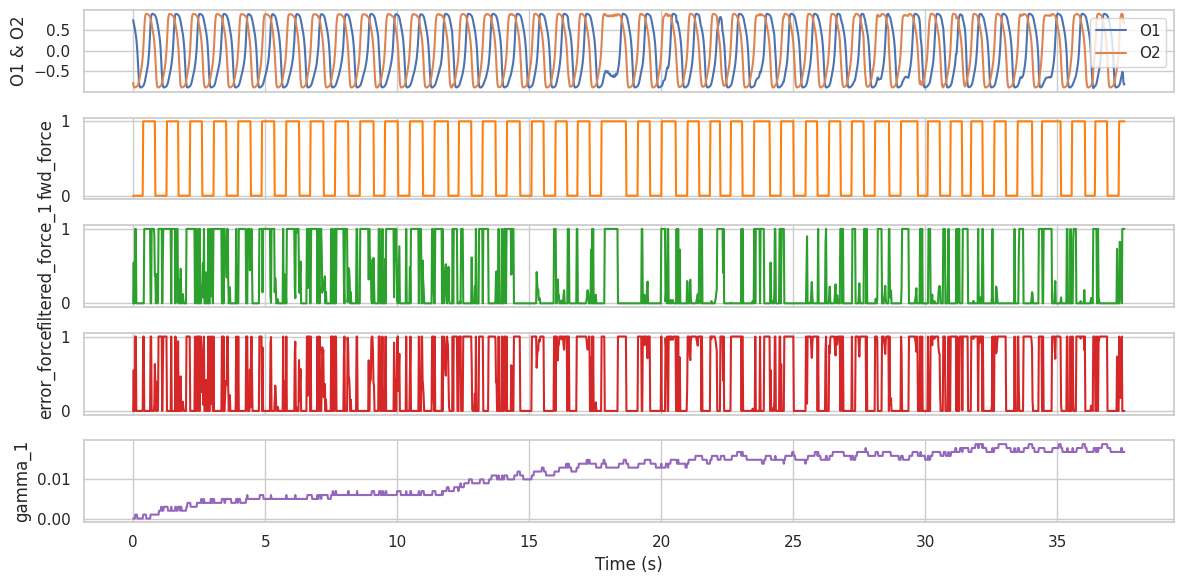

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv('data/integrated_data_gamma_quad4leg.csv')

# Use the correct column name for time
time = df['Time (s)']
O1 = df['o1']
O2 = df['o2']
fwd_force = df['fwd_force']
filtered_force = df['filtered_force_1']
error_force = df['error_force']
gamma_1 = df['gamma_1']

# Create subplots
fig, axs = plt.subplots(5, 1, figsize=(12, 6), sharex=True)

# Plot (a) O1 and O2
axs[0].plot(time, O1, label='O1')
axs[0].plot(time, O2, label='O2')
axs[0].set_ylabel('O1 & O2')
axs[0].legend()
axs[0].grid(True)

# Plot (b) fwd_force
axs[1].plot(time, fwd_force, color='tab:orange')
axs[1].set_ylabel('fwd_force')
axs[1].grid(True)

# Plot (c) filtered_force
axs[2].plot(time, filtered_force, color='tab:green')
axs[2].set_ylabel('filtered_force_1')
axs[2].grid(True)

# Plot (d) error_force
axs[3].plot(time, error_force, color='tab:red')
axs[3].set_ylabel('error_force')
axs[3].grid(True)

# Plot (e) gamma_1
axs[4].plot(time, gamma_1, color='tab:purple')
axs[4].set_ylabel('gamma_1')
axs[4].set_xlabel('Time (s)')
axs[4].grid(True)

plt.tight_layout()
plt.show()


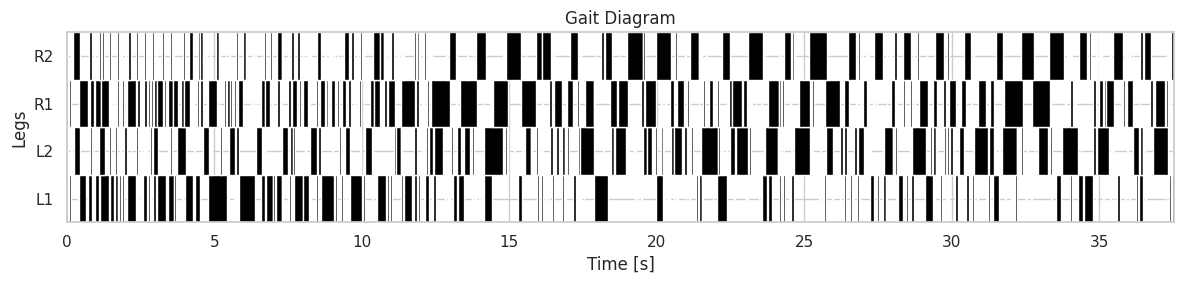

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
df = pd.read_csv('data/integrated_data_gamma_quad4leg.csv')

# Use correct columns
time = df['Time (s)']
forces = [
    df['filtered_force_1'],
    df['filtered_force_2'],
    df['filtered_force_3'],
    df['filtered_force_4']
]

leg_labels = ['L1', 'L2', 'R1', 'R2']  # Change as needed

# Threshold for stance detection (adjust!)
threshold = -0.0

# Create binary stance matrix
stance = []
for force in forces:
    stance.append(force > threshold)

stance = np.array(stance)

# Plot
fig, ax = plt.subplots(figsize=(12, 3))

# Loop over legs
for i in range(stance.shape[0]):
    # Find continuous stance phases
    in_stance = False
    start_time = None
    for j in range(len(time)):
        if stance[i, j] and not in_stance:
            in_stance = True
            start_time = time[j]
        elif not stance[i, j] and in_stance:
            in_stance = False
            end_time = time[j]
            ax.broken_barh([(start_time, end_time - start_time)],
                           (i - 0.5, 1.0),
                           facecolors='black')
    # If still in stance at end
    if in_stance:
        end_time = time.iloc[-1]
        ax.broken_barh([(start_time, end_time - start_time)],
                       (i - 0.5, 1.0),
                       facecolors='black')

# Labels and formatting
ax.set_yticks(range(len(leg_labels)))
ax.set_yticklabels(leg_labels)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Legs')
ax.set_title('Gait Diagram')
ax.set_xlim(time.iloc[0], time.iloc[-1])
ax.set_ylim(-0.5, len(leg_labels)-0.5)
ax.grid(True, axis='x')

plt.tight_layout()
plt.show()


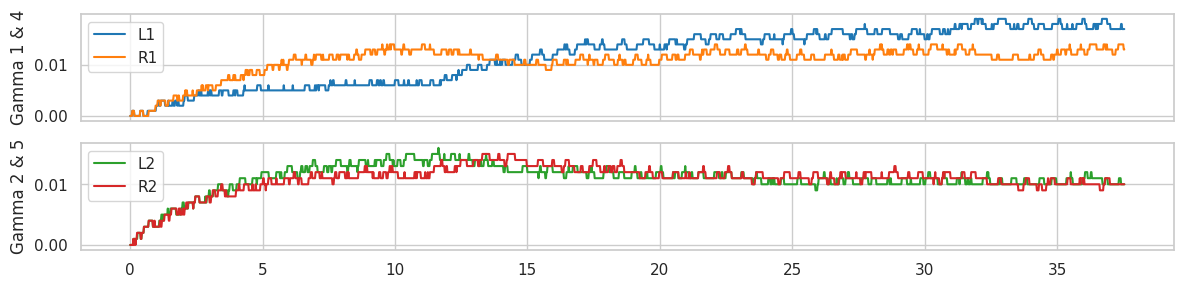

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv('data/integrated_data_gamma_quad4leg.csv')

# Extract time and gamma signals
time = df['Time (s)']
gamma_1 = df['gamma_1']
gamma_2 = df['gamma_2']
gamma_3 = df['gamma_3']
gamma_4 = df['gamma_4']

# Create subplots: 3 rows, 1 column
fig, axs = plt.subplots(2, 1, figsize=(12, 3), sharex=True)

# Plot gamma_1 and gamma_4
axs[0].plot(time, gamma_1, label='L1', color='tab:blue')
axs[0].plot(time, gamma_3, label='R1', color='tab:orange')
axs[0].set_ylabel('Gamma 1 & 4')
axs[0].legend()
axs[0].grid(True)

# Plot gamma_2 and gamma_5
axs[1].plot(time, gamma_2, label='L2', color='tab:green')
axs[1].plot(time, gamma_4, label='R2', color='tab:red')
axs[1].set_ylabel('Gamma 2 & 5')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()
